In [ ]:
import numpy as np
import jax.numpy as jnp
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_weights, compute_rhs, external_signal
from dyn_modelling.methods.neuralODE import init_vf_params, make_neural_ode, train, solve_node
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_loss, plot_parameter_evolution, plot_predictions, plot_phase_portrait


## 1. Build the lattice


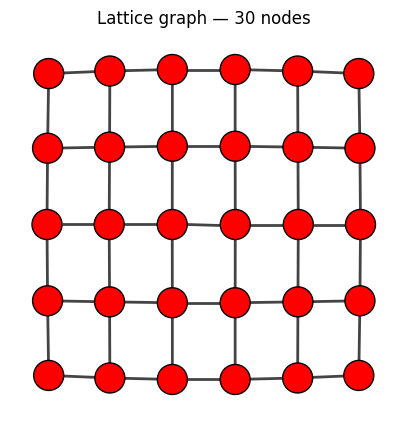

In [ ]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice


In [ ]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 80.0, 500.0
t_end, n_steps = 500.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


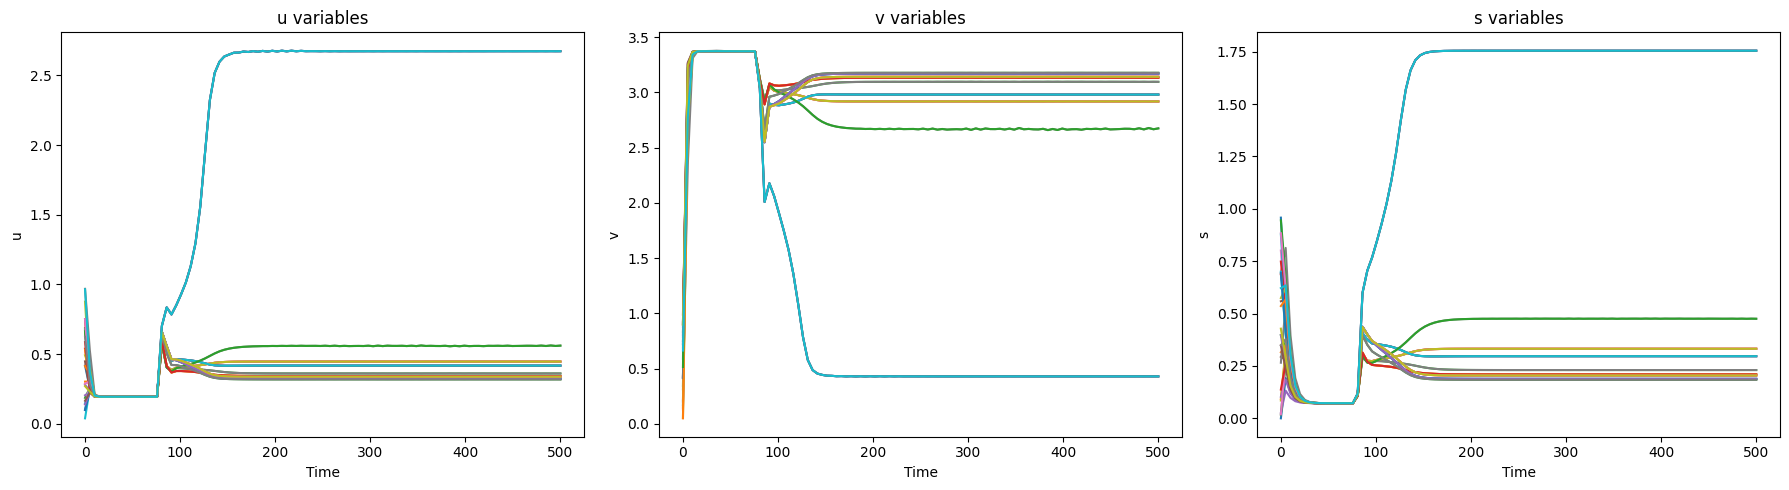

In [ ]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


In [ ]:
#y_noisy = add_noise(y, noise_level=0.1)
#plot_trajectories(t_eval, y_noisy)

## 5. NeuralODE

In [ ]:
ts = jnp.array(t_eval)       # (n_steps,)
y0 = jnp.array(y[:, 0])      # initial condition (3*N,)
y_true = jnp.array(y.T)      # (n_steps, 3*N)

vf_params = init_vf_params(data_size=3*N, width=64, depth=3)
loss_fn, grad_fn = make_neural_ode()

vf_params, loss_history = train(
    vf_params, y0, ts, y_true,
    loss_fn, grad_fn,
    n_epochs=5_000, lr=1e-3
)

[     0] loss = 237715.093750


jax.pure_callback failed
Traceback (most recent call last):
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\jax\_src\callback.py", line 92, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\jax\_src\callback.py", line 70, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\equinox\_errors.py", line 88, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you are using `jax.jit` instead?) and so further information about the 

JaxRuntimeError: INTERNAL: Buffer Definition Event: CpuCallback error calling callback: Traceback (most recent call last):
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\jax\_src\callback.py", line 815, in _wrapped_callback
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\jax\_src\callback.py", line 226, in _callback
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\jax\_src\callback.py", line 95, in pure_callback_impl
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\jax\_src\callback.py", line 70, in __call__
  File "d:\Projects\dyn-modelling\.venv\Lib\site-packages\equinox\_errors.py", line 88, in raises
_EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you are using `jax.jit` instead?) and so further information about the error cannot be displayed

In [ ]:
plot_loss(loss_history)

In [ ]:

from dyn_modelling.methods.neuralODE import solve_node


y_pred = np.array(solve_node(vf_params, y0, ts))  # (n_steps, 3*N)

plot_predictions(t_eval, y_pred, y_true)


In [ ]:
# phase portrait — only 2 cells
plot_phase_portrait(y_true, y_pred, n_cells=2)